In [1]:
import arviz as az
import pymc3 as pm
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import warnings

logsumexp = az.stats.stats_utils.logsumexp

WARNING (theano.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


In [2]:
xdata = np.linspace(0,50,100)
b0, b1, sigma = -2, 1, 3
ydata = np.random.normal(loc=b1*xdata + b0, scale=sigma)

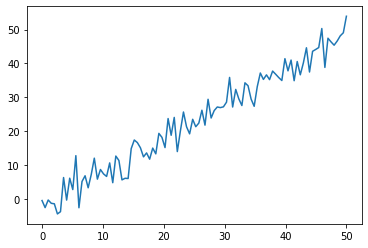

In [3]:
plt.plot(xdata, ydata);

In [4]:
sample_kwargs = {"draws": 1000, "chains": 4, "cores": 4}

In [10]:
with pm.Model() as model: # model specifications in PyMC3 are wrapped in a with-statement
    # Define data
    x_obs = pm.Data("x_obs", xdata)
    y_obs = pm.Data("y_obs", ydata)
    N = pm.Data("N", len(xdata))
    
    # Define priors
    sigma = pm.HalfNormal('sigma', sd=10)
    a0 = pm.Normal("a0", mu=0, sd=10)
    a1 = pm.Normal("a1", mu=0, sd=10)
    
    # Define likelihood
    likelihood = pm.Normal(
        'y', mu=a0 + a1 * x_obs, sd=sigma, observed=y_obs, shape=int(N.get_value())
        # I tried adding this shape argument but the error is still the same
    )
    
    # Inference!
    trace = pm.sample(**sample_kwargs) # draw posterior samples using NUTS sampling
    posterior_predictive = pm.sample_posterior_predictive(trace)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a1, a0, sigma]
Sampling 4 chains, 0 divergences: 100%|██████████| 6000/6000 [00:02<00:00, 2477.21draws/s]
The acceptance probability does not match the target. It is 0.8812628350593215, but should be close to 0.8. Try to increase the number of tuning steps.
The acceptance probability does not match the target. It is 0.8831918687257062, but should be close to 0.8. Try to increase the number of tuning steps.
100%|██████████| 4000/4000 [00:32<00:00, 123.42it/s]


In [11]:
with model:
    pm.set_data({"x_obs": [20], "y_obs": [18], "N": 1})
    trace = pm.sample(**sample_kwargs)
idata_1 = az.from_pymc3(trace=trace)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...


ValueError: Elemwise{sub,no_inplace}.grad returned object of shape (100,) as gradient term on input 0 of shape (1,)

In [12]:
dims = {"y":["time"],  "log_likelihood": ["time"]}
idata_kwargs = {"dims": dims}
idata = az.from_pymc3(
    trace=trace,
    posterior_predictive=posterior_predictive,
    **idata_kwargs,
)

Note that `xdata` is not stored anywhere in the InferenceData object returned by `from_pymc`. This gives some problems to write a `sel_observations` function for the `PyMC3SamplingWrapper` class.

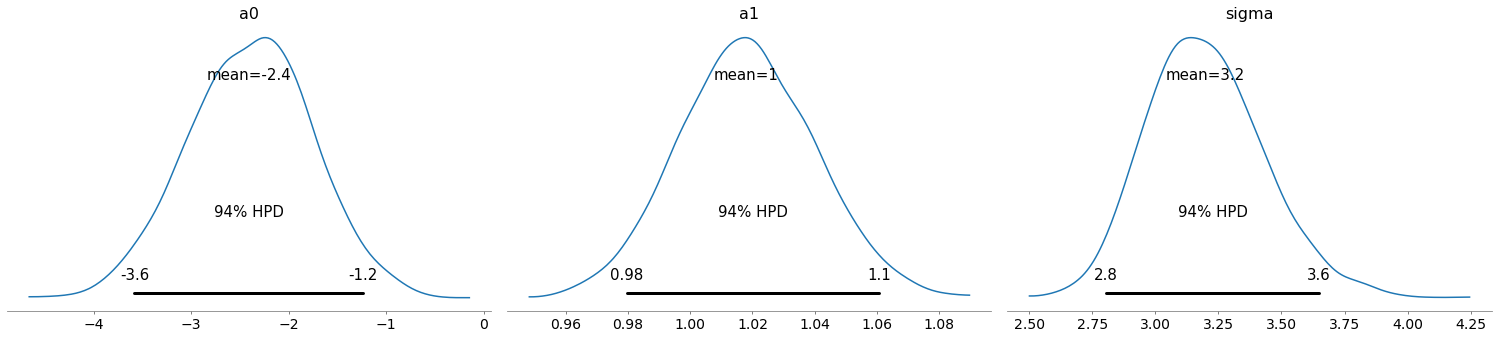

In [13]:
ax = az.plot_posterior(idata);

In [14]:
class PyMC3SamplingWrapper(az.SamplingWrapper):
    
    def sel_observations(self, idx, xdata=xdata):
        # I input xdata here, until a proper solution is agreed on in 
        # https://github.com/arviz-devs/arviz/issues/220
        ydata = self.idata_orig.observed_data.y.values
        mask = np.full_like(xdata, True, dtype=bool)
        mask[idx] = False
        N_obs = len(mask)
        N_ex = np.sum(~mask)
        observations = {
            "x_obs": xdata[mask],
            "y_obs": ydata[mask],
        }
        excluded = {
            "x_obs": xdata[~mask],
            "y_obs": ydata[~mask],
        }
        return observations, excluded
    
    def sample(self, modified_observed_data):
        """Could be generalized with some little work"""
        with self.model:
            pm.set_data(modified_observed_data)
            self.trace = pm.sample(**self.sample_kwargs)
            posterior_predictive = pm.sample_posterior_predictive(self.trace)
        return {"trace": self.trace, "posterior_predictive": posterior_predictive}
    
    def get_inference_data(self, fit):
        """Could be generalized"""
        idata = az.from_pystan(
            **fit,
            **self.idata_kwargs
        )
        return idata
    
    def log_likelihood__i(self, excluded_obs, idata__i):
        pm.set_data(excluded_obs)
        if len(self.model.observed_RVs) != 1:
            return None, None
        else:
            if self.dims is not None:
                coord_name = self.dims.get(self.model.observed_RVs[0].name)
            else:
                coord_name = None

        var = self.model.observed_RVs
        log_like = var.logp_elemwise

        def log_likelihood_vals_point(point):
            """Compute log likelihood for each observed point."""
            log_like_val = np.atleast_1d(log_like(point))
            if var.missing_values:
                log_like_val = log_like_val[~var.observations.mask]
            log_like_vals.append(log_like_val)
            return np.concatenate(log_like_vals)
        
        chain_likelihoods = []
        for chain in self.trace.chains:
            log_like = [log_likelihood_vals_point(point) for point in self.trace.points([chain])]
            chain_likelihoods.append(np.stack(log_like))
        return xr.DataArray(data=np.stack(chain_likelihoods), dims=("chain", "draw", *coord_name), name="log_likelihood")

In [11]:
pymc3_wrapper = PyMC3SamplingWrapper(
    model, 
    idata_orig=idata, 
    sample_kwargs=sample_kwargs, 
    idata_kwargs=idata_kwargs
)

In [12]:
def reloo(wrapper, loo_orig=None):
    if loo_orig is None:
        loo_orig = az.loo(wrapper.idata_orig, pointwise=True)
    reloo = loo_orig.copy()
    khats = reloo.pareto_k
    loo_i = reloo.loo_i
    scale = loo_orig.loo_scale
    if scale.lower() == "deviance":
        scale_value = -2
    elif scale.lower() == "log":
        scale_value = 1
    elif scale.lower() == "negative_log":
        scale_value = -1
    lppd_orig = loo_orig.p_loo + loo_orig.loo / scale_value
    n_data_points = loo_orig.n_data_points
    if np.any(khats>.7):
        lppd = np.empty(np.sum(khats.values>.7))
        for count, idx in enumerate(np.argwhere(khats.values>.7)):
            new_obs, excluded_obs = wrapper.sel_observations(idx)
            fit = wrapper.sample(new_obs)
            idata_idx = wrapper.get_inference_data(fit)
            log_like_idx = wrapper.log_likelihood__i(excluded_obs, idata_idx).values.flatten()
            loo_lppd_idx = scale_value * logsumexp(log_like_idx, b_inv=len(log_like_idx))
            khats[idx] = 0
            loo_i[idx] = loo_lppd_idx
            log_likelihood_i = idata_idx.sample_stats.log_likelihood.stack(sample=("chain", "draw"))
            log_likelihood = np.concatenate((log_likelihood_i.values, log_like_idx[None, ...]), axis=0)
            print(log_likelihood.shape)
            lppd[count] = np.sum(
                az.wrap_xarray_ufunc(
                    logsumexp,
                    log_likelihood,
                    func_kwargs={"b_inv": loo_orig.n_samples},
                    ufunc_kwargs={"n_dims": 1, "ravel": False},
                    input_core_dims= [["sample"]],
                )
            )
        reloo.loo = loo_i.values.sum()
        reloo.loo_se = (n_data_points * np.var(loo_i.values)) ** 0.5
        reloo.p_loo = lppd.mean() - reloo.loo / scale_value
        print("lppd_orig  :  recalculated")
        print(lppd_orig, lppd.mean())
        print(lppd_orig - reloo.loo / scale_value, reloo.p_loo)
        return reloo
    else:
        print("No problematic observations")
        return loo_orig

In [13]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    loo_orig = az.loo(idata, pointwise=True, scale="log")
loo_orig

/home/oriol/Public/arviz/arviz/stats/stats_utils.py:472: NumbaWarning: 
Compilation is falling back to object mode WITH looplifting enabled because Function "histogram" failed type inference due to: non-precise type pyobject
[1] During: typing of argument at /home/oriol/Public/arviz/arviz/stats/stats_utils.py (474)

File "arviz/stats/stats_utils.py", line 474:
def histogram(data):
    kcounts, _ = np.histogram(data, bins=[-np.Inf, 0.5, 0.7, 1, np.Inf])
    ^

  @conditional_jit
/home/oriol/venvs/arviz-dev/lib/python3.6/site-packages/numba/compiler.py:725: NumbaWarning: Function "histogram" was compiled in object mode without forceobj=True.

File "arviz/stats/stats_utils.py", line 473:
@conditional_jit
def histogram(data):
^

  self.func_ir.loc))
/home/oriol/venvs/arviz-dev/lib/python3.6/site-packages/numba/compiler.py:734: NumbaDeprecationWarning: 
Fall-back from the nopython compilation path to the object mode compilation path has been detected, this is deprecated behaviour.

For more

Computed from 2000 by 100 log-likelihood matrix

         Estimate       SE
elpd_loo  -246.55     6.61
p_loo        2.59        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.5]   (good)      100  100.0%
 (0.5, 0.7]   (ok)          0    0.0%
   (0.7, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%

In [15]:
loo_orig.pareto_k[47] = .8
loo_orig.pareto_k[93] = 1.3
reloo_data = reloo(pymc3_wrapper, loo_orig=loo_orig)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...


ValueError: Elemwise{sub,no_inplace}.grad returned object of shape (100,) as gradient term on input 0 of shape (99,)